# Supervised Learning Lab
In this lab, we will practice implementing and applying the various regressors and classifiers that we have covered so far in the course.

All  of  the  programming  assignments  are  to  be  done  in  Python  using  additional  libraries  specified  in  the  assignments.  There  are many  libraries  available,  some  of  which  we  will  be  using,  and  you  are  welcome  to  use  them  with  one  exception:  if  the  library  or  a  function  within  it  performs  the  specific  function  you  are  asked  to  code,  you  may  not  use  that  other  than  as  a  reference  to  compare  against. All  of  the  code  you  submit  must  be  your  own. Once you have completed an assignment, turn in your jupyter notebook with all the outputs shown.


### Preliminaries

Before you begin, make sure you have a properly operating Python environment with the Pandas, NumPy, Matplotlib, and Sci-kit Learn packages installed. If setup correctly, the following line of code should run without error:

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn

Also make sure you have the following datasets downloaded from the assignment page and placed in a `datasets/` directory of your project folder. **Please do not change the folder structure to minimize issues when grading.**

In [15]:
penguins_fn = "./datasets/penguins_v2.csv"
pokemon_fn = "./datasets/pokemon.csv"
movies_fn = "./datasets/movies.csv"

Datasets descriptions

- Penguins: Contains biological information about individual penguins of different species on three different islands.
- Pokemon: Contains attack, defense, and other stats information for all pokemon of the famous Pokemon game.
- Movies: Contains financial, IMDB scores, and other info for movies that made over $50,000,000 between 2000-2024.

## Part 1: Implement K-Nearest Neighbors

To begin the lab, you will improve your understanding of the sklearn API by implementing your own KNN model from scratch. Create a class that mimics the sklearn structure by writing code for `model.predict()` (I have implemented `model.fit()` and `model.score()` for you). You can assume your model will accept NumPy arrays directly, though you are welcome to code in the ability to accept Pandas dataframes.

To test your algorithm, we will be using an updated Penguins dataset from Lab 1. There are no missing values, so you will not need to clean this dataset like you did in Lab 1. We want to test your KNN's ability to classify penguin species based on Bill Length and Bill Depth. The testing code is provided in a separate cell to evaluate the effectiveness of your model. You can also compare to sklearn's KNN algorithm to verify your results.

*Hint: For the prediction function. You are welcome to use sklearn's `sklearn.metrics.pairwise.euclidean_distances` function to compute distances between each pair of points. `np.bincount` may also be helpful.*

In [16]:
class myKNN:
    def __init__(self):
        pass

    def fit(self, X, y, k=3):
        self.X_train = X
        self.y_train = y
        self.k = k

    def predict(self, X):
        # Your code here
        from sklearn.metrics.pairwise import euclidean_distances

        distances = euclidean_distances(X, self.X_train)

        k = min(self.k, len(self.y_train))
        predictions = []

        for row in distances:
            nn_indices = np.argsort(row)[:k]
            nn_labels = self.y_train[nn_indices]
            counts = np.bincount(nn_labels)
            pred = np.argmax(counts)
            predictions.append(pred)

        return np.array(predictions)
    
    def score(self, predictions, targets):
        return np.mean(predictions == targets)

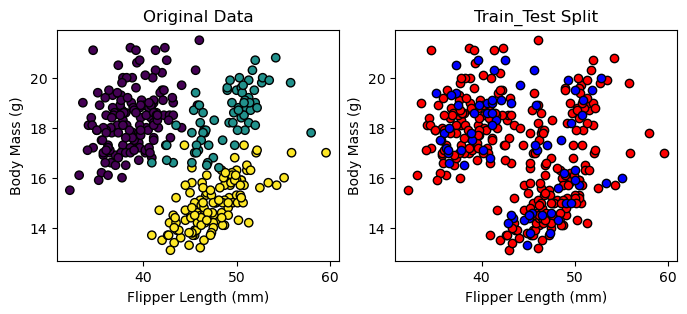

In [17]:
penguins = pd.read_csv(penguins_fn)

X = penguins[["Bill Length (mm)", "Bill Depth (mm)"]].to_numpy()
y = penguins["Species"].astype('category').cat.codes.to_numpy()

# Provide Train/Test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Visualizations
figure, axes = plt.subplots(1, 2, figsize=(8, 3))
axes[0].scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolor='k')
axes[0].set_title("Original Data")
axes[0].set_xlabel("Flipper Length (mm)")
axes[0].set_ylabel("Body Mass (g)")
axes[1].scatter(X_train[:, 0], X_train[:, 1], c="red", edgecolor='k')
axes[1].scatter(X_test[:, 0], X_test[:, 1], c="blue", edgecolor='k')
axes[1].set_xlabel("Flipper Length (mm)")
axes[1].set_ylabel("Body Mass (g)")
axes[1].set_title("Train_Test Split")
plt.show()

In [18]:
# Testing code
model = myKNN()
model.fit(X_train, y_train, 2)
y_pred = model.predict(X_test)
print("Accuracy:", model.score(y_pred, y_test))

# k = 1:   0.9565217391304348
# k = 2:   0.9855072463768116
# k = 3:   0.9710144927536232
# k = 10:  0.9710144927536232
# k = 50:  0.9130434782608695
# k = 100: 0.8260869565217391
# k = 500: 0.5072463768115942

Accuracy: 0.9855072463768116


#### Answer the following questions in the markdown cell below: 

#### After implementing your model, try using different k-values. Which k-value worked best? Was the amount of improvement over the baseline model more or less than you expected?

When k = 2, the accuracy was its highest. The amount of improvement over the baseline model was more than I expected as I thought  k = 3 would give the highest accuracy.

## Part 2: Testing Regressors

In this part of the lab, you will practice using the various regressors built into sklearn. We will build various regression models for the penguins dataset.

We want to predict flipper length based on other penguin properties. To start, I've provided a simple linear regression model with body mass as the only input. The code below evaluates this model given the provided train/test split data. This linear model is also visualized for convenience.

For this part, you need to code variations to drive to improve on this baseline method. Possible comparison could include following variations:
- Including Bill Depth and Bill Length as variables (You can redefine the train/test split if needed).
- Using Lasso, Ridge, or Elastic regression models
- Using Bayesian Ridge Regression, GLMs, or any of the models found in [sklearn.linear_model](https://scikit-learn.org/stable/api/sklearn.linear_model.html)

Try at least 5 variations of regressors to see which has the best `model.score()` ($R^2$ value) on the test set. You can visualize the model if helpful, but it is not required.

Baseline Model R^2: 0.773413180769273


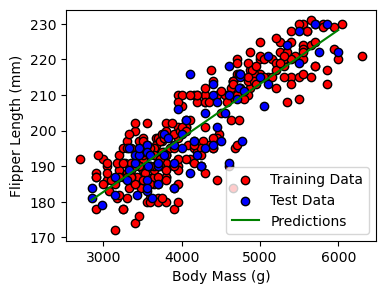

In [19]:
# Train Test Split
penguins = pd.read_csv(penguins_fn)

X = penguins["Body Mass (g)"].to_numpy().reshape(-1, 1)
y = penguins["Flipper Length (mm)"].to_numpy()

# Provide Train/Test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Baseline Model Linear Regression
from sklearn.linear_model import LinearRegression
linreg = LinearRegression()
linreg.fit(X_train, y_train)
y_pred = linreg.predict(X_test)
print("Baseline Model R^2:", linreg.score(X_test, y_test))

# Sort X_test and y_pred for better plotting
sorted_indices = np.argsort(X_test.flatten())
X_test = X_test[sorted_indices]
y_test = y_test[sorted_indices]
y_pred = y_pred[sorted_indices]

# Visualizations
figure = plt.figure(figsize=(4, 3))
plt.scatter(X_train, y_train, c='red', edgecolor='k', label='Training Data')
plt.scatter(X_test, y_test, c='blue', edgecolor='k', label='Test Data')
plt.plot(X_test, y_pred, color='green', label='Predictions')
plt.xlabel("Body Mass (g)")
plt.ylabel("Flipper Length (mm)")
plt.legend()
plt.show()

In [20]:
# Your variations here
import sklearn.linear_model as lm

# Lasso Linear Regression
linreg = lm.Lasso()
linreg.fit(X_train, y_train)
y_pred = linreg.predict(X_test)
print("Lasso Model R^2:", linreg.score(X_test, y_test))

# Ridge Linear Regression
linreg = lm.Ridge()
linreg.fit(X_train, y_train)
y_pred = linreg.predict(X_test)
print("Ridge Model R^2:", linreg.score(X_test, y_test))

# Elastic Linear Regression
linreg = lm.ElasticNet()
linreg.fit(X_train, y_train)
y_pred = linreg.predict(X_test)
print("Elastic Model R^2:", linreg.score(X_test, y_test))

# Bayesian Ridge Linear Regression
linreg = lm.BayesianRidge()
linreg.fit(X_train, y_train)
y_pred = linreg.predict(X_test)
print("Bayesian Ridge Model R^2:", linreg.score(X_test, y_test))

# GLM Linear Regression
linreg = lm.GammaRegressor()
linreg.fit(X_train, y_train)
y_pred = linreg.predict(X_test)
print("GLM Model R^2:", linreg.score(X_test, y_test))

Lasso Model R^2: 0.7734066321255234
Ridge Model R^2: 0.7734131804061832
Elastic Model R^2: 0.7734098586112886
Bayesian Ridge Model R^2: 0.7733349095057911
GLM Model R^2: 0.7717744779225292


#### Answer the following questions in the markdown cell below: 

#### Which model worked best? Was the amount of improvement over the baseline model more or less than you expected? Why do you think this was the case? 

The baseline linear regression model had the highest accuracy. As my results show the other models were slightly less accurate, with the Ridge model being the second most accurate, I would say the overall improvement is less than expected. I believe this to be the case because linear regression is the baseline.

## Part 3: Testing Classifiers

In this part of the lab, you will practice using the various classifiers built into sklearn.

Like in Lab 1, we want to see if we classify the species of a penguin based on the bill length and bill depth. Additionally, we want to classify the sex of a penguin based on bill depth and body mass. The train/test split of the data is provided as well as a dummy classifier (always predicts the same thing).

For this part, you need to compare various classification models. Models to try to include:
- KNearestNeighbors (KNeighborsClassifier)
- Gaussian Naive Bayes (GaussianNB)
- QDA (QuadraticDiscriminantAnalysis)
- Gaussian Process (GaussianProcessClassifier)
- Support Vector Machine (SVC)

You may try other methods you find on sklearn, but for now, do not use any decission trees (e.g. random forest, ada boost) or any deep learning/MLP models. You are also welcome to try different hyperparameter setups, such as K-value for KNN or kernel function for SVM. 

Try at least 5 variations on species classification and 5 variations on sex classification. In each setup, see which classifier has the best `model.score()` (Accuracy value) on the test set. Also, plot the decision boundary for the highest performing model in both tasks (code provided).

Dummy Classifier Accuracy for Species: 0.5072463768115942
Dummy Classifier Accuracy for Sex: 0.43478260869565216


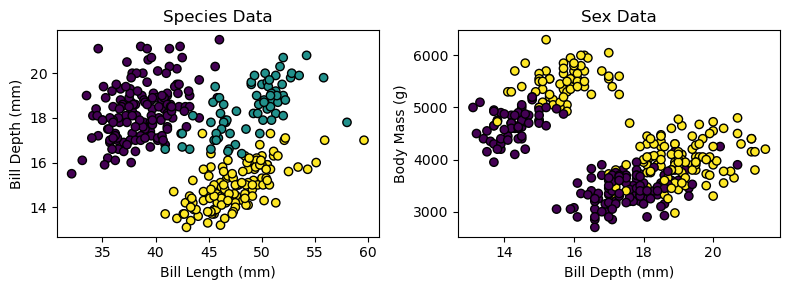

In [21]:
penguins = pd.read_csv(penguins_fn)

X1 = penguins[["Bill Length (mm)", "Bill Depth (mm)"]].to_numpy()
y1 = penguins["Species"].astype('category').cat.codes.to_numpy()

X2 = penguins[["Bill Depth (mm)", "Body Mass (g)"]].to_numpy()
y2 = penguins["Sex"].astype('category').cat.codes.to_numpy()

# Provide Train/Test split
from sklearn.model_selection import train_test_split
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=42)
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

# Dummy Classifier
from sklearn.dummy import DummyClassifier
dummy1 = DummyClassifier(strategy="most_frequent")
dummy1.fit(X1_train, y1_train)
y_pred1 = dummy1.predict(X1_test)
print("Dummy Classifier Accuracy for Species:", dummy1.score(X1_test, y1_test))

dummy2 = DummyClassifier(strategy="most_frequent")
dummy2.fit(X2_train, y2_train)
y_pred2 = dummy2.predict(X2_test)
print("Dummy Classifier Accuracy for Sex:", dummy2.score(X2_test, y2_test))

# Visualizations
figure, axes = plt.subplots(1, 2, figsize=(8, 3))
axes[0].scatter(X1[:, 0], X1[:, 1], c=y1, cmap='viridis', edgecolor='k')
axes[0].set_title("Species Data")
axes[0].set_xlabel("Bill Length (mm)")
axes[0].set_ylabel("Bill Depth (mm)")
axes[1].scatter(X2[:, 0], X2[:, 1], c=y2, cmap='viridis', edgecolor='k')
axes[1].set_title("Sex Data")
axes[1].set_xlabel("Bill Depth (mm)")
axes[1].set_ylabel("Body Mass (g)")
plt.tight_layout()
plt.show()


In [22]:
def plot_decision_boundary(model, X, y, title="Decision Boundary", feat1="Feature 1", feat2="Feature 2"):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                         np.arange(y_min, y_max, 0.1))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k')
    plt.title(title)
    plt.xlabel(feat1)
    plt.ylabel(feat2)
    plt.show()

KNN Species Accuracy: 0.9710144927536232
KNN Sex Accuracy: 0.6666666666666666
GaussianNB Species Accuracy: 0.9565217391304348
GaussianNB Sex Accuracy: 0.782608695652174
QDA Species Accuracy: 0.9855072463768116
QDA Sex Accuracy: 0.8260869565217391


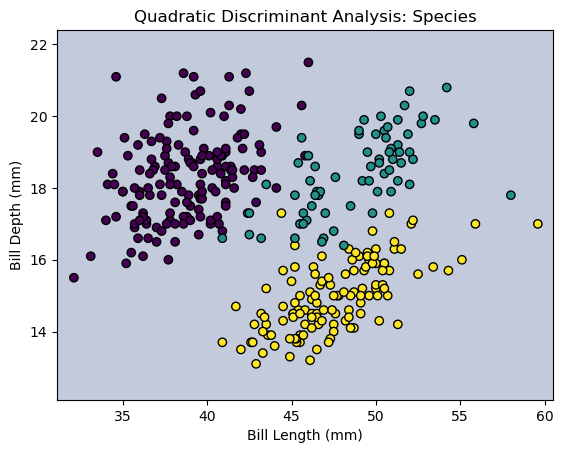

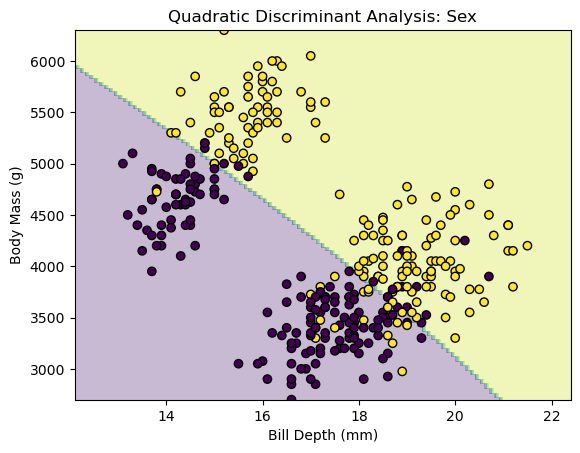

GaussianP Species Accuracy: 0.9710144927536232
GaussianP Sex Accuracy: 0.7246376811594203
SVC Species Accuracy: 0.9710144927536232
SVC Sex Accuracy: 0.5362318840579711


In [23]:
# Your variations here
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.svm import SVC

# KNN
knn = KNeighborsClassifier()
knn.fit(X1_train, y1_train)
print("KNN Species Accuracy:", knn.score(X1_test, y1_test))
knn.fit(X2_train, y2_train)
print("KNN Sex Accuracy:", knn.score(X2_test, y2_test))
# plot_decision_boundary(knn, X1, y1, "K-Nearest Neighbors: Species", "Bill Length (mm)", "Bill Depth (mm)")
# plot_decision_boundary(knn, X2, y2, "K-Nearest Neighbors: Sex", "Bill Depth (mm)", "Body Mass (g)")

# Gaussian Naive Bayes
gnb = GaussianNB()
gnb.fit(X1_train, y1_train)
print("GaussianNB Species Accuracy:", gnb.score(X1_test, y1_test))
gnb.fit(X2_train, y2_train)
print("GaussianNB Sex Accuracy:", gnb.score(X2_test, y2_test))
# plot_decision_boundary(gnb, X1, y1, "Gaussian Naive Bayes: Species", "Bill Length (mm)", "Bill Depth (mm)")
# plot_decision_boundary(gnb, X2, y2, "Gaussian Naive Bayes: Sex", "Bill Depth (mm)", "Body Mass (g)")

# QDA
qda = QuadraticDiscriminantAnalysis()
qda.fit(X1_train, y1_train)
print("QDA Species Accuracy:", qda.score(X1_test, y1_test))
qda.fit(X2_train, y2_train)
print("QDA Sex Accuracy:", qda.score(X2_test, y2_test))
plot_decision_boundary(qda, X1, y1, "Quadratic Discriminant Analysis: Species", "Bill Length (mm)", "Bill Depth (mm)")
plot_decision_boundary(qda, X2, y2, "Quadratic Discriminant Analysis: Sex", "Bill Depth (mm)", "Body Mass (g)")

# Gaussian Process
gp = GaussianProcessClassifier()
gp.fit(X1_train, y1_train)
print("GaussianP Species Accuracy:", gp.score(X1_test, y1_test))
gp.fit(X2_train, y2_train)
print("GaussianP Sex Accuracy:", gp.score(X2_test, y2_test))
# plot_decision_boundary(gp, X1, y1, "Gaussian Process: Species", "Bill Length (mm)", "Bill Depth (mm)")
# plot_decision_boundary(gp, X2, y2, "Gaussian Process: Sex", "Bill Depth (mm)", "Body Mass (g)")

# SVC
sv = SVC()
sv.fit(X1_train, y1_train)
print("SVC Species Accuracy:", sv.score(X1_test, y1_test))
sv.fit(X2_train, y2_train)
print("SVC Sex Accuracy:", sv.score(X2_test, y2_test))
# plot_decision_boundary(sv, X1, y1, "Support Vector: Species", "Bill Length (mm)", "Bill Depth (mm)")
# plot_decision_boundary(sv, X2, y2, "Support Vector: Sex", "Bill Depth (mm)", "Body Mass (g)")

#### Answer the following questions in the markdown cell below: 

#### Which model worked best classifying species? Which model worked best classifying sex? Were these two models the same? Why do you think this was the case? Was the amount of improvement over the variations between models more or less than you expected?

The QDA model worked best for classifying both species and sex of the penguins. I think a singular model being the best for both species and sex is good and shows it is the model to use. The amount of variation between the models was more than I expected.

## Part 4: Developing your own model

Now it's your turn to build your own model. Using the movies or pokemon dataset, build a regressor or classifier to predict a property of your choice. Compare at least 3 different variations of your model and defend the model that you chose. Critically evaluate the effectiveness of your model.

Present your findings in the code and markup cells that follow. Use print statements and plots to justify your arguments. Make sure your findings are neatly organized and easy for the grader to find. For this section, you will be graded on your presentation quality in addition to the correctness of your code.

*Note: In the movies dataset, if you want to grab the data for a single genre, you can use the code: `df = movies[movies["Genres"].str.contains(keyword, na=False)]`.*

*Note: If you have another dataset you would like to build a supervised learning model for, you may do so if you get preapproval from Dr. Hart.*

   #                   Name Type 1  Type 2  Total  HP  Attack  Defense  \
0  1              Bulbasaur  Grass  Poison    318  45      49       49   
1  2                Ivysaur  Grass  Poison    405  60      62       63   
2  3               Venusaur  Grass  Poison    525  80      82       83   
3  3  VenusaurMega Venusaur  Grass  Poison    625  80     100      123   
4  4             Charmander   Fire     NaN    309  39      52       43   

   Sp. Atk  Sp. Def  Speed  Generation  Legendary  
0       65       65     45           1      False  
1       80       80     60           1      False  
2      100      100     80           1      False  
3      122      120     80           1      False  
4       60       50     65           1      False  
Dummy Classifier Accuracy for Legendery: 0.9375


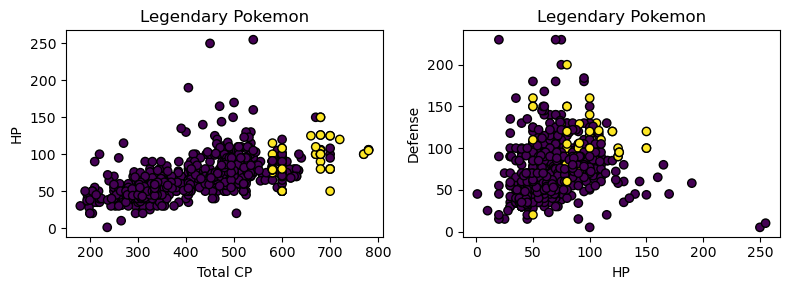

KNN Legendary Total CP, HP Accuracy: 0.98125
KNN Legendary HP, Defense Accuracy: 0.91875


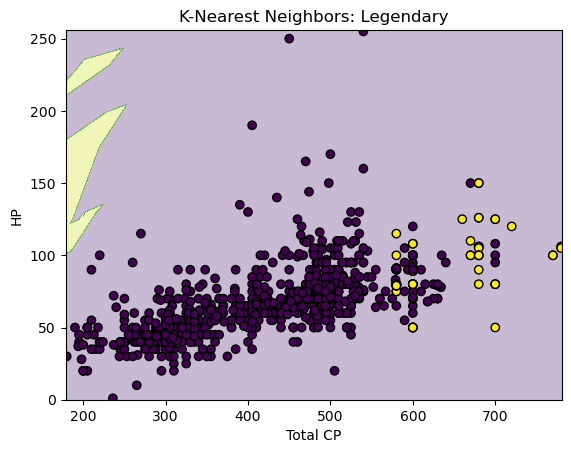

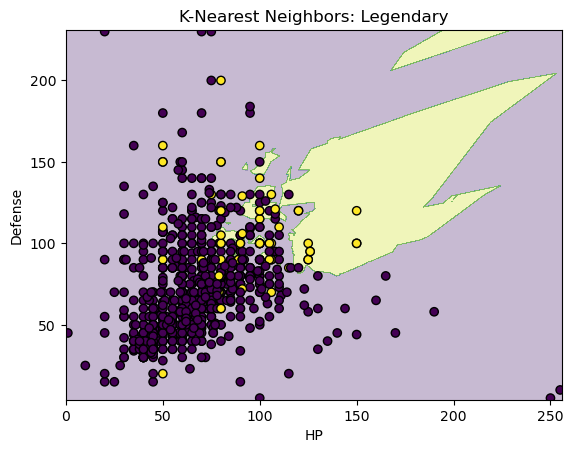

QDA Legendary Total CP, HP Accuracy: 0.93125
QDA Legendary Total HP, Defense Accuracy: 0.93125


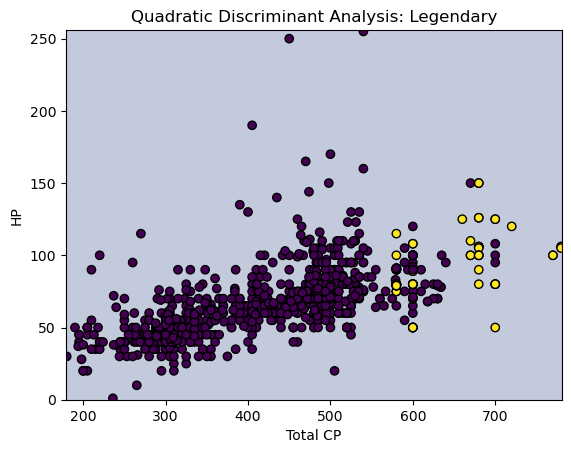

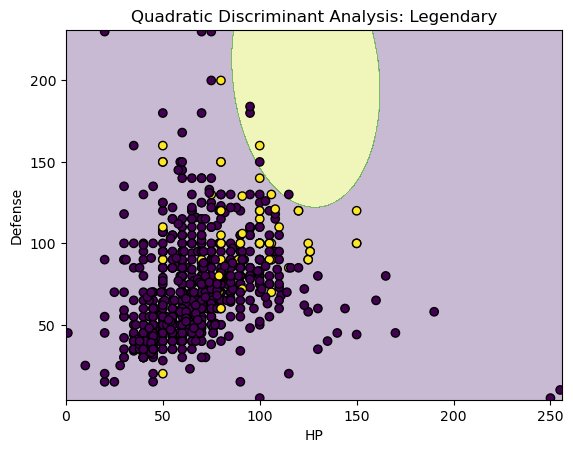

SVC Legendary Total CP, HP Accuracy: 0.95
SVC Legendary Total HP, Defense Accuracy: 0.9375


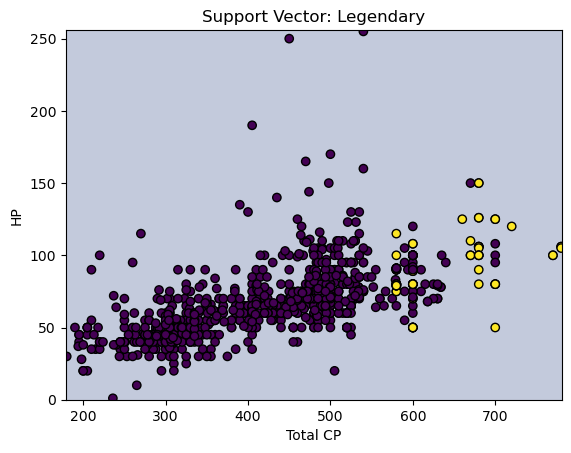

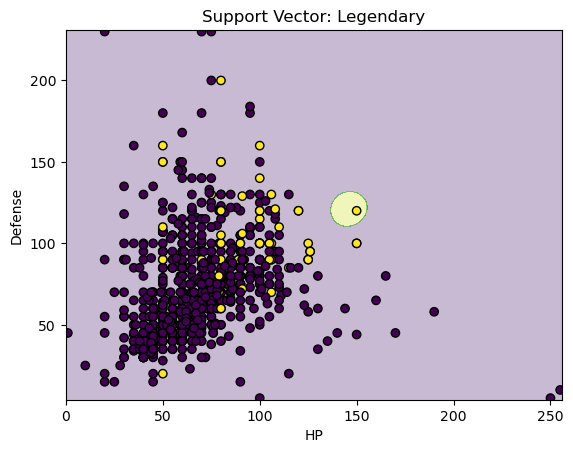

In [24]:
pokemon = pd.read_csv(pokemon_fn)

print(pokemon.head())

X1 = pokemon[["Total", "HP"]].to_numpy()
y1 = pokemon["Legendary"].astype('category').cat.codes.to_numpy()

X2 = pokemon[["HP", "Defense"]].to_numpy()
y2 = pokemon["Legendary"].astype('category').cat.codes.to_numpy()

# Provide Train/Test split
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=42)
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

# Dummy Classifier
dummy1 = DummyClassifier(strategy="most_frequent")
dummy1.fit(X1_train, y1_train)
y_pred1 = dummy1.predict(X1_test)
print("Dummy Classifier Accuracy for Legendery:", dummy1.score(X1_test, y1_test))

"""
dummy2 = DummyClassifier(strategy="most_frequent")
dummy2.fit(X2_train, y2_train)
y_pred2 = dummy2.predict(X2_test)
print("Dummy Classifier Accuracy for Type 2:", dummy2.score(X2_test, y2_test))
"""

# Visualizations
figure, axes = plt.subplots(1, 2, figsize=(8, 3))
axes[0].scatter(X1[:, 0], X1[:, 1], c=y1, cmap='viridis', edgecolor='k')
axes[0].set_title("Legendary Pokemon")
axes[0].set_xlabel("Total CP")
axes[0].set_ylabel("HP")
axes[1].scatter(X2[:, 0], X2[:, 1], c=y2, cmap='viridis', edgecolor='k')
axes[1].set_title("Legendary Pokemon")
axes[1].set_xlabel("HP")
axes[1].set_ylabel("Defense")
plt.tight_layout()
plt.show()

# KNN
knn = KNeighborsClassifier()
knn.fit(X1_train, y1_train)
print("KNN Legendary Total CP, HP Accuracy:", knn.score(X1_test, y1_test))
knn.fit(X2_train, y2_train)
print("KNN Legendary HP, Defense Accuracy:", knn.score(X2_test, y2_test))
plot_decision_boundary(knn, X1, y1, "K-Nearest Neighbors: Legendary", "Total CP", "HP")
plot_decision_boundary(knn, X2, y2, "K-Nearest Neighbors: Legendary", "HP", "Defense")

# Gaussian Naive Bayes
"""
gnb = GaussianNB()
gnb.fit(X1_train, y1_train)
print("GaussianNB Legendary Total CP, HP Accuracy:", gnb.score(X1_test, y1_test))
gnb.fit(X2_train, y2_train)
print("GaussianNB Legendary Total HP, Defense Accuracy:", gnb.score(X2_test, y2_test))
plot_decision_boundary(gnb, X1, y1, "Gaussian Naive Bayes: Legendary", "Total CP", "HP")
plot_decision_boundary(gnb, X2, y2, "Gaussian Naive Bayes: Legendary", "HP", "Defense")
"""

# QDA
qda = QuadraticDiscriminantAnalysis()
qda.fit(X1_train, y1_train)
print("QDA Legendary Total CP, HP Accuracy:", qda.score(X1_test, y1_test))
qda.fit(X2_train, y2_train)
print("QDA Legendary Total HP, Defense Accuracy:", qda.score(X2_test, y2_test))
plot_decision_boundary(qda, X1, y1, "Quadratic Discriminant Analysis: Legendary", "Total CP", "HP")
plot_decision_boundary(qda, X2, y2, "Quadratic Discriminant Analysis: Legendary", "HP", "Defense")

# Gaussian Process
"""
gp = GaussianProcessClassifier()
gp.fit(X1_train, y1_train)
print("GaussianP Legendary Total CP, HP Accuracy:", gp.score(X1_test, y1_test))
gp.fit(X2_train, y2_train)
print("GaussianP Legendary Total HP, Defense Accuracy:", gp.score(X2_test, y2_test))
plot_decision_boundary(gp, X1, y1, "Gaussian Process: Legendary", "Total CP", "HP")
plot_decision_boundary(gp, X2, y2, "Gaussian Process: Legendary", "HP", "Defense")
"""

# SVC
sv = SVC()
sv.fit(X1_train, y1_train)
print("SVC Legendary Total CP, HP Accuracy:", sv.score(X1_test, y1_test))
sv.fit(X2_train, y2_train)
print("SVC Legendary Total HP, Defense Accuracy:", sv.score(X2_test, y2_test))
plot_decision_boundary(sv, X1, y1, "Support Vector: Legendary", "Total CP", "HP")
plot_decision_boundary(sv, X2, y2, "Support Vector: Legendary", "HP", "Defense")

#### Using the Legendary Pokemon from the Pokemon dataset, there is a high accuracy for test data predictions based on total CP, HP, and Defense.

The KNN model for Total CP and HP was the most accurate at 98.125%. This is surprising given that models such as SVC and QDA - which ranked 2nd and 3rd, respectively, in accuracy - are more intricate and usually the more accurate models.

KNN makes predictions based on a data points' neighboring data points. As Pokemon themselves share similar statistics within their type and rating, and the number of legendary Pokemon is limited, it makes sense that KNN would best fit this data.